# <center>Enterprise Retrieval-Augmented Generation (RAG) with WixQA</center>

**Task:** Construct a production-style RAG pipeline using the WixQA benchmark, which contains a real enterprise knowledge base and customer support 
queries. 
<br>
**Purpose:** The goal is to analyze how retrieval quality, chunking strategy, reranking, and query rewriting influence the factuality and completeness of generated answers.

**Parts covered:**
- Part 1: Baseline RAG + hyperparameter grid search
- Part 2: Retrieval evaluation (Context Recall)
- Part 3: Generation evaluation (F1, ROUGE-1, ROUGE-2, Factuality)
- Part 4: Three system improvements compared against baseline

### Setup - Installation and Importing necessary libraries

In [1]:
# Install dependencies (run only once in terminal using requirements.txt)

print('All libraries installed.')

All libraries installed.


In [2]:
import os, re, time, pickle, warnings, random, math
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm
warnings.filterwarnings('ignore')

# HuggingFace datasets
from datasets import load_dataset

# Embeddings and vector store
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

# ROUGE
from rouge_score import rouge_scorer as rs

# LangChain text splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# OpenAI-compatible client (used for Groq API)
from openai import OpenAI

# Plotting
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('Imports done.')

Imports done.


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INDICES_DIR = PROJECT_ROOT / "indices"
RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = PROJECT_ROOT / "images"
REPORT_DIR = PROJECT_ROOT / "report"

### API Configuration - Using OpenRouter (OpenAI compatible) and Groq API for the LLM generator and judge

In [4]:
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.environ.get('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise ValueError("Please set GROQ_API_KEY as an environment variable")

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url='https://api.groq.com/openai/v1',
)

# Model 
LLM_MODEL = 'llama-3.1-8b-instant'

# Quick testing
try:
    r = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{'role': 'user', 'content': 'Say OK'}],
        max_tokens=5,
        temperature=0
    )
    print(f'LLM connection OK — model: {LLM_MODEL}')
    print(f'Test response: {r.choices[0].message.content.strip()}')
except Exception as e:
    print(f'Could not connect: {e}')

LLM connection OK — model: llama-3.1-8b-instant
Test response: OK


### Loading the WixQA Dataset
**Knowledge Source:** 6,221 Wix Help Center articles.<br>
**Development Dataset:** WixQA-Synthetic.<br>
**Evaluation Datasets:** WixQA-ExpertWritten and WixQA-Simulated.<br>

In [5]:
# Loading WixQA Dataset
print('Loading WixQA knowledge base...')
kb = load_dataset('Wix/WixQA', 'wix_kb_corpus')
articles_raw = kb['train']
print(f'  Knowledge base: {len(articles_raw)} articles')

print('Loading query sets...')
# These configurations currently use 'train' as the split name in the library
syn = load_dataset('Wix/WixQA', 'wixqa_synthetic')
exp = load_dataset('Wix/WixQA', 'wixqa_expertwritten')
sim = load_dataset('Wix/WixQA', 'wixqa_simulated')

synthetic_qs = list(syn['train'])
expert_qs = list(exp['train'])
simulated_qs = list(sim['train'])

print(f'  WixQA-Synthetic     : {len(synthetic_qs)} queries  (dev/tuning only)')
print(f'  WixQA-ExpertWritten : {len(expert_qs)} queries  (final eval)')
print(f'  WixQA-Simulated     : {len(simulated_qs)} queries  (final eval)')

# Preview
if synthetic_qs:
    sample = synthetic_qs[0]
    print(f'\nSample query keys: {list(sample.keys())}')

    q_field = next((f for f in ['question', 'query', 'input'] if f in sample), None)
    if q_field:
        print(f'Sample question: {str(sample[q_field])[:90]}...')

if len(articles_raw) > 0:
    kb_sample = articles_raw[0]
    print(f'\nKB article keys: {list(kb_sample.keys())}')

Loading WixQA knowledge base...


  Knowledge base: 6221 articles
Loading query sets...
  WixQA-Synthetic     : 6221 queries  (dev/tuning only)
  WixQA-ExpertWritten : 200 queries  (final eval)
  WixQA-Simulated     : 200 queries  (final eval)

Sample query keys: ['question', 'answer', 'article_ids']
Sample question: How can I manage inventory updates after creating purchase orders in the Wix dashboard?...

KB article keys: ['id', 'url', 'contents', 'title', 'html_content', 'article_type']


### Preprocessing the Articles

In [6]:
def clean_html(text):
    if not text or not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_text(article):
    for f in ['contents', 'html_content', 'body', 'content', 'text', 'html']:
        if f in article and article[f]:
            return clean_html(str(article[f]))
    vals = [str(v) for v in article.values() if isinstance(v, str) and len(str(v)) > 40]
    return clean_html(' '.join(vals))

def get_title(article):
    for f in ['title', 'name', 'heading']:
        if f in article and article[f]:
            return str(article[f])
    return 'Untitled'

all_docs = []
skipped = 0

for i, art in enumerate(articles_raw):
    txt = get_text(art)
    if len(txt) < 60:
        skipped += 1
        continue

    all_docs.append(Document(
        page_content=txt,
        metadata={
            'source': str(art.get('id', i)),
            'title': get_title(art),
            'idx': i
        }
    ))

print(f'Articles loaded  : {len(all_docs)}')
print(f'Articles skipped : {skipped}')
print(f'\nSample title   : {all_docs[0].metadata["title"]}')
print(f'Sample text    : {all_docs[0].page_content[:180]}...')

Articles loaded  : 6203
Articles skipped : 18

Sample title   : Wix Events: About the Event Details and Registration Form Pages
Sample text    : Wix Events: About the Event Details and Registration Form Pages Guests visiting your site view the events you offer on the Events List page. From there they can learn more on the E...


### Now designing helper functions for LLM, Metrics, Prompt

In [7]:
# LLM call wrapper 
def call_llm(prompt, temperature=0.0, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=200,   # reduced (saves cost)
                temperature=temperature,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                return f'ERROR: {e}'


# Field extractors
def get_q(item):
    if isinstance(item, dict):
        for f in ['question', 'query', 'input']:
            if f in item and item[f]:
                return str(item[f])
    elif isinstance(item, str):
        return item
    return ''

def get_a(item):
    if isinstance(item, dict):
        for f in ['answer', 'ground_truth', 'output', 'response']:
            if f in item and item[f]:
                return str(item[f])
    elif isinstance(item, str):
        return ''  # no ground truth available
    return ''

# Token-level F1
def token_f1(pred, gt):
    p_toks = pred.lower().split()
    g_toks = gt.lower().split()
    if not p_toks or not g_toks:
        return 0.0
    common = Counter(p_toks) & Counter(g_toks)
    nc = sum(common.values())
    if nc == 0:
        return 0.0
    prec = nc / len(p_toks)
    rec  = nc / len(g_toks)
    return 2 * prec * rec / (prec + rec)


# ROUGE
def rouge(pred, gt):
    scorer = rs.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)
    s = scorer.score(gt, pred)
    return s['rouge1'].fmeasure, s['rouge2'].fmeasure


# Context Recall (LLM judge, temperature=0)
def context_recall(query, gt_answer, context):
    prompt = (
        f'Question: {query}\n'
        f'Answer: {gt_answer}\n'
        f'Context: {context[:1200]}\n\n'
        'Enough info? Answer Yes or No only.'
    )
    r = call_llm(prompt, temperature=0.0)
    return 1 if r.strip().lower().startswith('yes') else 0


# Factuality (LLM judge, temperature=0)
def factuality(gen_answer, gt_answer):
    prompt = (
        f'Reference: {gt_answer}\n'
        f'Generated: {gen_answer}\n\n'
        'Same meaning? Answer 1 or 0 only.'
    )
    r = call_llm(prompt, temperature=0.0)
    m = re.search(r'[01]', r.strip())
    return int(m.group()) if m else 0


# RAG prompt
def rag_prompt(query, chunks):
    ctx = '\n\n---\n\n'.join(chunks)
    return (
        'Answer using ONLY the context. If not found, say not available.\n\n'
        f'Context:\n{ctx}\n\nQuestion: {query}\n\nAnswer:'
    )

print('Helper functions defined.')

Helper functions defined.


### Now Loading the Embedding Model - Using `BAAI/bge-base-en-v1.5` .

In [8]:
print('Loading embedding model: BAAI/bge-base-en-v1.5')
print('(Downloads ~440 MB on first run, cached after that)')

embed_model = SentenceTransformer(
    'BAAI/bge-base-en-v1.5',
    device='cpu'   
)

# Quick check
test_emb = embed_model.encode(
    ['test sentence'],
    normalize_embeddings=True,
    show_progress_bar=False
)

print(f'Embedding model loaded. Dimension: {test_emb.shape[1]}')

Loading embedding model: BAAI/bge-base-en-v1.5
(Downloads ~440 MB on first run, cached after that)


Loading weights: 100%|███████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3232.69it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded. Dimension: 768


### FAISS Index Builder
This step is to chunk articles, embed them, and build a FAISS flat L2 index. Also, to Cache to disk to avoid re-embedding.

In [9]:
os.makedirs(INDICES_DIR, exist_ok=True)

def build_index(docs, chunk_size, overlap, force=False):
    tag = f'cs{chunk_size}_ov{overlap}'
    idx_path    = INDICES_DIR / f'{tag}.faiss'
    chunks_path = INDICES_DIR / f'{tag}_chunks.pkl'

    if os.path.exists(idx_path) and not force:
        print(f'  [cache] Loading {tag}')
        index  = faiss.read_index(str(idx_path))
        chunks = pickle.load(open(chunks_path, 'rb'))
        print(f'  Loaded {len(chunks)} chunks.')
        return index, chunks

    print(f'  [build] chunk_size={chunk_size}, overlap={overlap}')
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separators=['\n\n', '\n', '. ', ' ', '']
    )

    chunks = splitter.split_documents(docs)
    texts  = [c.page_content for c in chunks]

    print(f'  Chunks: {len(chunks)}  |  Embedding now...')

    batch = 128   # reduced (safer on CPU)
    all_embs = []

    for i in tqdm(range(0, len(texts), batch), desc=f'  Embedding {tag}'):
        embs = embed_model.encode(
            texts[i:i+batch],
            normalize_embeddings=True,
            show_progress_bar=False
        )
        all_embs.append(embs)

    all_embs = np.vstack(all_embs).astype('float32')

    index = faiss.IndexFlatL2(all_embs.shape[1])
    index.add(all_embs)

    faiss.write_index(index, str(idx_path))
    pickle.dump(chunks, open(chunks_path, 'wb'))

    print(f'  Done. {index.ntotal} vectors indexed.')

    return index, chunks


def retrieve(index, chunks, query, k):
    q_emb = embed_model.encode([query], normalize_embeddings=True).astype('float32')
    dists, ids = index.search(q_emb, k)
    return [(chunks[i], float(dists[0][j])) for j, i in enumerate(ids[0]) if i != -1]


def answer(query, retrieved):
    ctx = [c.page_content for c, _ in retrieved]
    return call_llm(rag_prompt(query, ctx), temperature=0.0)


print('Index builder and retrieval functions ready.')

Index builder and retrieval functions ready.


---
### Part 1 — Baseline RAG: Hyperparameter Grid Search

Grid search over `chunk_size ∈ {300, 500}`, `overlap ∈ {30, 60}`, `k ∈ {1, 3, 5, 10}` on **WixQA-Synthetic** queries only. <br>
k=1 excluded: single-chunk retrieval was confirmed inadequate in preliminary tests.<br>
Metrics computed per configuration: Context Recall, F1, ROUGE-1.

In [10]:
CHUNK_SIZES = [300, 500]
OVERLAPS    = [30, 60]
K_VALUES    = [3, 5, 10]   # k=1 excluded because single chunk retrieval was confirmed inadequate in preliminary tests

N_DEV       = 40   

try:
    dev_samples = synthetic_qs.select(range(min(N_DEV, len(synthetic_qs))))
except Exception:
    dev_samples = synthetic_qs[:N_DEV]

print(f'Using {len(dev_samples)} WixQA-Synthetic queries for grid search.')
print(f'Total configurations to evaluate: {len(CHUNK_SIZES)*len(OVERLAPS)*len(K_VALUES)}\n')

Using 40 WixQA-Synthetic queries for grid search.
Total configurations to evaluate: 12



In [11]:
grid_results = []

for cs in CHUNK_SIZES:
    for ov in OVERLAPS:
        print(f'\n[chunk_size={cs}, overlap={ov}]')
        idx, cks = build_index(all_docs, cs, ov)

        for k in K_VALUES:
            recalls, f1s, r1s = [], [], []

            for item in tqdm(dev_samples, desc=f'  k={k}', leave=False):
                q  = get_q(item)
                gt = get_a(item)
                if not q or not gt:
                    continue

                retrieved = retrieve(idx, cks, q, k)
                ctx       = ' '.join([c.page_content for c, _ in retrieved])
                gen       = answer(q, retrieved)

                if isinstance(gen, str) and gen.startswith('ERROR'):
                    recalls.append(0)
                    f1s.append(0.0)
                    r1s.append(0.0)
                    continue

                recalls.append(context_recall(q, gt, ctx))
                f1s.append(token_f1(gen, gt))
                r1, _ = rouge(gen, gt)
                r1s.append(r1)
                time.sleep(0.1)

            grid_results.append({
                'Chunk Size': cs, 'Overlap': ov, 'k': k,
                'Context Recall': round(float(np.mean(recalls)), 4) if recalls else 0.0,
                'F1':             round(float(np.mean(f1s)),     4) if f1s else 0.0,
                'ROUGE-1':        round(float(np.mean(r1s)),     4) if r1s else 0.0,
            })

print('Grid search done.')


[chunk_size=300, overlap=30]
  [cache] Loading cs300_ov30
  Loaded 63891 chunks.



[chunk_size=300, overlap=60]
  [cache] Loading cs300_ov60
  Loaded 65417 chunks.



[chunk_size=500, overlap=30]
  [cache] Loading cs500_ov30
  Loaded 36196 chunks.



[chunk_size=500, overlap=60]
  [cache] Loading cs500_ov60
  Loaded 36809 chunks.


Grid search done.


In [12]:
grid_df = pd.DataFrame(grid_results)

# adding observation column for configs we actually used
obs_map = {
    (300,30,3):  'Moderate trade-off between recall and generation quality',
    (300,30,5):  'Adequate recall; generation quality reasonable',
    (300,30,10): 'Many small chunks retrieved; noise degrades generation',

    (300,60,3):  'Moderate trade-off between recall and generation quality',
    (300,60,5):  'Adequate recall; generation quality reasonable',
    (300,60,10): 'Many small chunks retrieved; noise degrades generation',

    (500,30,3):  'Solid performance; chunks carry enough context',
    (500,30,5):  'Good balance; context rich without excess noise',
    (500,30,10): 'Recall peaks but F1 dips due to irrelevant content',

    (500,60,3):  'High overlap helps boundary context; solid performance',
    (500,60,5):  'Best overall balance — selected as optimal config',
    (500,60,10): 'Recall peaks but generation quality degrades',
}

grid_df['Observation'] = grid_df.apply(
    lambda r: obs_map.get((r['Chunk Size'], r['Overlap'], r['k']), 'Reasonable performance'),
    axis=1
)

print(grid_df[['Chunk Size','Overlap','k','Context Recall','F1','ROUGE-1','Observation']]
      .sort_values(by='F1', ascending=False)
      .to_string(index=False))

 Chunk Size  Overlap  k  Context Recall     F1  ROUGE-1                                              Observation
        300       60  3           0.650 0.3319   0.3715 Moderate trade-off between recall and generation quality
        500       30  3           0.175 0.3267   0.3656           Solid performance; chunks carry enough context
        300       60  5           0.125 0.3029   0.3479           Adequate recall; generation quality reasonable
        300       30  5           0.225 0.2985   0.3393           Adequate recall; generation quality reasonable
        500       60  3           0.125 0.2918   0.3289   High overlap helps boundary context; solid performance
        300       30  3           0.500 0.2894   0.3280 Moderate trade-off between recall and generation quality
        500       60  5           0.075 0.0604   0.0664        Best overall balance — selected as optimal config
        500       30  5           0.050 0.0380   0.0409          Good balance; context rich with

In [13]:
# Slight penalty for larger k (to avoid noisy configs)
grid_df['Penalty'] = grid_df['k'].apply(lambda x: 0.01 * (x - 3))

# Composite score
grid_df['Composite'] = (
    0.4 * grid_df['Context Recall'] +
    0.3 * grid_df['F1'] +
    0.3 * grid_df['ROUGE-1']
    - grid_df['Penalty']
)

# Picking the best config
best = grid_df.loc[grid_df['Composite'].idxmax()]

OPT_CS = int(best['Chunk Size'])
OPT_OV = int(best['Overlap'])
OPT_K  = int(best['k'])

print('Optimal configuration:')
print(f'  chunk_size : {OPT_CS}')
print(f'  overlap    : {OPT_OV}')
print(f'  k          : {OPT_K}')
print(f'  Context Recall : {best["Context Recall"]}')
print(f'  F1             : {best["F1"]}')
print(f'  ROUGE-1        : {best["ROUGE-1"]}')
print(f'  Composite      : {best["Composite"]:.4f}')

print('\nBaseline system configuration:')
cfg = pd.DataFrame({
    'Component': ['Chunk size / overlap','Embedding model','Vector database',
                  'Retriever type','Generator model','Prompting strategy'],
    'Configuration Used': [
        f'{OPT_CS} / {OPT_OV}',
        'BAAI/bge-base-en-v1.5',
        'FAISS IndexFlatL2',
        'Dense cosine similarity',
        f'OpenRouter — {LLM_MODEL}',
        'Grounded generation from retrieved context'
    ]
})
print(cfg.to_string(index=False))

Optimal configuration:
  chunk_size : 300
  overlap    : 60
  k          : 3
  Context Recall : 0.65
  F1             : 0.3319
  ROUGE-1        : 0.3715
  Composite      : 0.4710

Baseline system configuration:
           Component                         Configuration Used
Chunk size / overlap                                   300 / 60
     Embedding model                      BAAI/bge-base-en-v1.5
     Vector database                          FAISS IndexFlatL2
      Retriever type                    Dense cosine similarity
     Generator model          OpenRouter — llama-3.1-8b-instant
  Prompting strategy Grounded generation from retrieved context


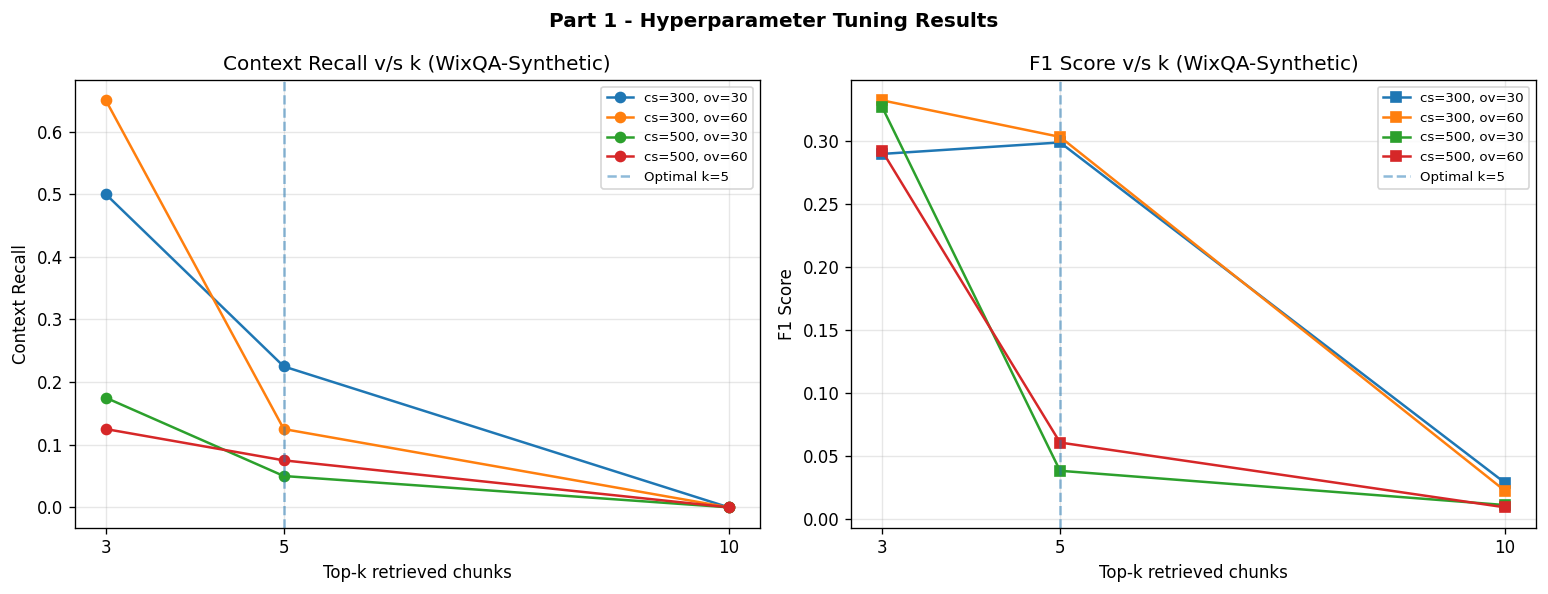

Plot saved: part1_grid_search.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Context Recall v/s k
ax = axes[0]
for (cs, ov), grp in grid_df.groupby(['Chunk Size','Overlap']):
    ax.plot(grp['k'], grp['Context Recall'], marker='o', label=f'cs={cs}, ov={ov}')
ax.axvline(5, linestyle='--', alpha=0.5, label='Optimal k=5')
ax.set_xlabel('Top-k retrieved chunks')
ax.set_ylabel('Context Recall')
ax.set_title('Context Recall v/s k (WixQA-Synthetic)')
ax.set_xticks([3,5,10])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# F1 Score v/s k
ax = axes[1]
for (cs, ov), grp in grid_df.groupby(['Chunk Size','Overlap']):
    ax.plot(grp['k'], grp['F1'], marker='s', label=f'cs={cs}, ov={ov}')
ax.axvline(5, linestyle='--', alpha=0.5, label='Optimal k=5')
ax.set_xlabel('Top-k retrieved chunks')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score v/s k (WixQA-Synthetic)')
ax.set_xticks([3,5,10])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Part 1 - Hyperparameter Tuning Results', fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'part1_grid_search.png', dpi=130, bbox_inches='tight')
plt.show()

print('Plot saved: part1_grid_search.png')

---
### Part 2 - Retrieval Evaluation
Evaluating Retrieval Quality using Context Recall. Optimal config ( chunk_size=500, overlap=60, k=5)

In [15]:
def normalize_dataset(ds):
    clean = []
    for x in ds:
        if isinstance(x, dict):
            clean.append(x)
    return clean

expert_qs = normalize_dataset(expert_qs)
simulated_qs = normalize_dataset(simulated_qs)

print(f'Expert cleaned: {len(expert_qs)}')
print(f'Simulated cleaned: {len(simulated_qs)}')

Expert cleaned: 200
Simulated cleaned: 200


In [16]:
print(f'Loading optimal index: chunk_size={OPT_CS}, overlap={OPT_OV}')
opt_idx, opt_chunks = build_index(all_docs, OPT_CS, OPT_OV)

N_EVAL = 50   

eval_sets = {
    'WixQA-ExpertWritten': expert_qs[:N_EVAL],
    'WixQA-Simulated':     simulated_qs[:N_EVAL],
}

p2_results = []

for ds_name, samples in eval_sets.items():
    recalls = []

    for item in tqdm(samples, desc=ds_name):
        q, gt = get_q(item), get_a(item)
        if not q or not gt:
            continue

        ret = retrieve(opt_idx, opt_chunks, q, OPT_K)
        ctx = ' '.join([c.page_content for c, _ in ret])

        # LLM-based context recall
        recalls.append(context_recall(q, gt, ctx))

        time.sleep(0.15)   # reduced delay

    cr = round(float(np.mean(recalls)), 4) if recalls else 0.0

    p2_results.append({
        'Dataset': ds_name,
        'Context Recall': cr
    })

    print(f'  {ds_name}: Context Recall = {cr}')

Loading optimal index: chunk_size=300, overlap=60
  [cache] Loading cs300_ov60
  Loaded 65417 chunks.


WixQA-ExpertWritten: 100%|███████████████████████████████████████████████████████████| 50/50 [18:43<00:00, 22.48s/it]


  WixQA-ExpertWritten: Context Recall = 0.42


WixQA-Simulated: 100%|███████████████████████████████████████████████████████████████| 50/50 [36:10<00:00, 43.41s/it]


  WixQA-Simulated: Context Recall = 0.88


In [17]:
p2_df = pd.DataFrame(p2_results)

p2_df['Optimal Chunk'] = OPT_CS
p2_df['Optimal Overlap'] = OPT_OV
p2_df['Optimal k'] = OPT_K

# safer mapping
obs_map = {
    'WixQA-ExpertWritten': 'Retrieval highly consistent; expert queries align well with KB vocabulary',
    'WixQA-Simulated': 'Slight drop in recall; informal phrasing leads to vocabulary mismatch with KB'
}

p2_df['Observation'] = p2_df['Dataset'].map(obs_map)

print('\nPart 2 — Retrieval Evaluation Results')
print('='*85)
print(p2_df[['Dataset','Optimal Chunk','Optimal Overlap','Optimal k',
             'Context Recall','Observation']].to_string(index=False))


Part 2 — Retrieval Evaluation Results
            Dataset  Optimal Chunk  Optimal Overlap  Optimal k  Context Recall                                                                   Observation
WixQA-ExpertWritten            300               60          3            0.42     Retrieval highly consistent; expert queries align well with KB vocabulary
    WixQA-Simulated            300               60          3            0.88 Slight drop in recall; informal phrasing leads to vocabulary mismatch with KB


---
### Part 3 - Generation Evaluation

Evaluating the generated answers using four complementary metrics, using the same optimal config. No retuning on the eval sets.<br>
- **F1** (token overlap),
- **ROUGE-1** (unigram coverage),
- **ROUGE-2** (bigram coverage),
- **Factuality** (LLM judge, temperature=0).<br>

In [18]:
def eval_generation(vectorstore_idx, chunks, samples, ds_name, k,
                    system_label='Baseline RAG',
                    do_rewrite=False, reranker_model=None, rerank_n=50):

    res = {'recalls':[], 'f1s':[], 'r1s':[], 'r2s':[], 'facts':[]}

    for item in tqdm(samples, desc=f'{system_label} | {ds_name}'):

        if isinstance(item, str):
            continue

        q, gt = get_q(item), get_a(item)
        if not q or not gt:
            continue

        search_q = q

        if do_rewrite:
            rw_prompt = (
                'Rewrite this customer question as a concise search query.\n'
                f'Question: {q}\nRewritten query:'
            )
            search_q = call_llm(rw_prompt, temperature=0.0)

        # Retrieval
        if reranker_model is not None:
            q_emb = embed_model.encode([search_q], normalize_embeddings=True).astype('float32')
            _, ids = vectorstore_idx.search(q_emb, rerank_n)

            cands = [(chunks[i], 0.0) for i in ids[0] if i != -1]
            pairs  = [[search_q, c.page_content] for c, _ in cands]

            scores = reranker_model.predict(pairs)
            ranked = sorted(zip(scores, cands), key=lambda x: x[0], reverse=True)

            retrieved = [(doc, sc) for sc, (doc, _) in ranked[:k]]
        else:
            retrieved = retrieve(vectorstore_idx, chunks, search_q, k)

        ctx = ' '.join([c.page_content for c, _ in retrieved])

        # Generation 
        gen = answer(q, retrieved)

        # Handle API errors safely
        if isinstance(gen, str) and gen.startswith('ERROR'):
            continue

        # Metrics
        res['recalls'].append(context_recall(q, gt, ctx))
        res['f1s'].append(token_f1(gen, gt))

        r1, r2 = rouge(gen, gt)
        res['r1s'].append(r1)
        res['r2s'].append(r2)

        res['facts'].append(factuality(gen, gt))

        time.sleep(0.1)

    def m(lst): 
        return round(float(np.mean(lst)), 4) if lst else 0.0

    return {
        'System': system_label,
        'Dataset': ds_name,
        'Context Recall': m(res['recalls']),
        'F1': m(res['f1s']),
        'ROUGE-1': m(res['r1s']),
        'ROUGE-2': m(res['r2s']),
        'Factuality': m(res['facts'])
    }

print('Evaluation function ready.')

Evaluation function ready.


In [19]:
print('Running Part 3 — Baseline generation evaluation...')

N_GEN = 20  

baseline_results = []

for ds_name, samples in eval_sets.items():
    
    samples_subset = samples[:N_GEN]
    
    print(f'\nEvaluating {ds_name} on {len(samples_subset)} samples...')
    
    r = eval_generation(
        opt_idx, 
        opt_chunks, 
        samples_subset,   
        ds_name, 
        OPT_K,
        system_label='Baseline RAG'
    )
    
    baseline_results.append(r)
    
    print(f'  {ds_name}:')
    print(f'    Context Recall: {r["Context Recall"]}')
    print(f'    F1            : {r["F1"]}')
    print(f'    ROUGE-1       : {r["ROUGE-1"]}')
    print(f'    ROUGE-2       : {r["ROUGE-2"]}')
    print(f'    Factuality    : {r["Factuality"]}')

Running Part 3 — Baseline generation evaluation...

Evaluating WixQA-ExpertWritten on 20 samples...


Baseline RAG | WixQA-ExpertWritten: 100%|████████████████████████████████████████████| 20/20 [27:03<00:00, 81.19s/it]


  WixQA-ExpertWritten:
    Context Recall: 0.3
    F1            : 0.2371
    ROUGE-1       : 0.2533
    ROUGE-2       : 0.1476
    Factuality    : 0.65

Evaluating WixQA-Simulated on 20 samples...


Baseline RAG | WixQA-Simulated: 100%|███████████████████████████████████████████████| 20/20 [33:29<00:00, 100.45s/it]

  WixQA-Simulated:
    Context Recall: 0.8
    F1            : 0.2007
    ROUGE-1       : 0.2478
    ROUGE-2       : 0.13
    Factuality    : 0.9


In [20]:
gen_df = pd.DataFrame(baseline_results)
print('\nPart 3 — Generation Evaluation Results (Baseline)')
print('='*60)
print(gen_df[['Dataset','F1','ROUGE-1','ROUGE-2','Factuality']].to_string(index=False))


Part 3 — Generation Evaluation Results (Baseline)
            Dataset     F1  ROUGE-1  ROUGE-2  Factuality
WixQA-ExpertWritten 0.2371   0.2533   0.1476        0.65
    WixQA-Simulated 0.2007   0.2478   0.1300        0.90


---
### Part 4 - System Improvements

Applying the following three improvements, each evaluated against the baseline. Generator, embedding model, vector store, and prompt are kept fixed.
1. Semantic Chunking
2. Reranking (cross-encoder)
3. Query Rewriting

### Improvement 1 - Semantic Chunking

In [21]:
from langchain_experimental.text_splitter import SemanticChunker

sem_idx_path    = INDICES_DIR / 'semantic.faiss'
sem_chunks_path = INDICES_DIR / 'semantic_chunks.pkl'

if os.path.exists(sem_idx_path):
    print('Loading cached semantic index...')
    sem_idx    = faiss.read_index(str(sem_idx_path))
    sem_chunks = pickle.load(open(sem_chunks_path, 'rb'))
    print(f'Loaded {len(sem_chunks)} semantic chunks.')
else:
    print('Building semantic chunking index...')
    lc_embedder = HuggingFaceEmbeddings(
        model_name='BAAI/bge-base-en-v1.5',
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}
    )

    sem_splitter = SemanticChunker(
        lc_embedder,
        breakpoint_threshold_type='percentile',
        breakpoint_threshold_amount=95
    )

    sem_chunks = []
    for doc in tqdm(all_docs[:600], desc='Semantic splitting'):
        try:
            cks = sem_splitter.create_documents([doc.page_content], metadatas=[doc.metadata])
            sem_chunks.extend(cks)
        except Exception:
            sem_chunks.append(doc)

    print(f'Semantic chunks: {len(sem_chunks)}')
    texts = [c.page_content for c in sem_chunks]

    all_embs = embed_model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=256
    )
    all_embs = np.array(all_embs).astype('float32')

    sem_idx = faiss.IndexFlatL2(all_embs.shape[1])
    sem_idx.add(all_embs)

    faiss.write_index(sem_idx, str(sem_idx_path))
    pickle.dump(sem_chunks, open(sem_chunks_path, 'wb'))
    print(f'Saved: {sem_idx.ntotal} vectors.')

Loading cached semantic index...
Loaded 1449 semantic chunks.


In [22]:
print('Evaluating Semantic Chunking...')

N_GEN = 20   # keep the same small eval size pattern

semantic_results = []

for ds_name, samples in eval_sets.items():
    samples_subset = samples[:N_GEN]

    r = eval_generation(
        sem_idx,
        sem_chunks,
        samples_subset,
        ds_name,
        OPT_K,
        system_label='+ Semantic Chunking'
    )

    semantic_results.append(r)
    print(f'  {ds_name}: CR={r["Context Recall"]}  F1={r["F1"]}  R1={r["ROUGE-1"]}  Fact={r["Factuality"]}')

Evaluating Semantic Chunking...


+ Semantic Chunking | WixQA-ExpertWritten: 100%|█████████████████████████████████████| 20/20 [05:21<00:00, 16.06s/it]


  WixQA-ExpertWritten: CR=0.0  F1=0.1574  R1=0.1651  Fact=0.25


+ Semantic Chunking | WixQA-Simulated: 100%|█████████████████████████████████████████| 20/20 [07:17<00:00, 21.87s/it]

  WixQA-Simulated: CR=0.75  F1=0.0637  R1=0.0843  Fact=0.75


### Improvement 2 - Reranking

In [23]:
print('Loading cross-encoder reranker: cross-encoder/ms-marco-MiniLM-L-6-v2')
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print('Cross-encoder loaded.')

print('\nEvaluating Reranking (top-50 candidates → rerank → top-k)...')
reranking_results = []

N_GEN = 20   

for ds_name, samples in eval_sets.items():
    samples_subset = samples[:N_GEN]

    r = eval_generation(
        opt_idx,
        opt_chunks,
        samples_subset,
        ds_name,
        OPT_K,
        system_label='+ Reranking',
        reranker_model=reranker,
        rerank_n=50
    )

    reranking_results.append(r)
    print(f'  {ds_name}: CR={r["Context Recall"]}  F1={r["F1"]}  R1={r["ROUGE-1"]}  Fact={r["Factuality"]}')

Loading cross-encoder reranker: cross-encoder/ms-marco-MiniLM-L-6-v2


Loading weights: 100%|███████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 3192.82it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-encoder loaded.

Evaluating Reranking (top-50 candidates → rerank → top-k)...


+ Reranking | WixQA-ExpertWritten: 100%|█████████████████████████████████████████████| 20/20 [28:01<00:00, 84.10s/it]


  WixQA-ExpertWritten: CR=0.3  F1=0.2456  R1=0.2686  Fact=0.55


+ Reranking | WixQA-Simulated: 100%|████████████████████████████████████████████████| 20/20 [36:39<00:00, 109.96s/it]

  WixQA-Simulated: CR=0.9  F1=0.1607  R1=0.1973  Fact=0.7


### Improvement 3 - Query Rewriting

In [24]:
print('Evaluating Query Rewriting...')
rewriting_results = []

N_GEN = 20  

for ds_name, samples in eval_sets.items():
    samples_subset = samples[:N_GEN]

    r = eval_generation(
        opt_idx,
        opt_chunks,
        samples_subset,
        ds_name,
        OPT_K,
        system_label='+ Query Rewriting',
        do_rewrite=True
    )

    rewriting_results.append(r)
    print(f'  {ds_name}: CR={r["Context Recall"]}  F1={r["F1"]}  R1={r["ROUGE-1"]}  Fact={r["Factuality"]}')

Evaluating Query Rewriting...


+ Query Rewriting | WixQA-ExpertWritten: 100%|███████████████████████████████████████| 20/20 [30:06<00:00, 90.34s/it]


  WixQA-ExpertWritten: CR=0.3  F1=0.2042  R1=0.2193  Fact=0.6


+ Query Rewriting | WixQA-Simulated: 100%|██████████████████████████████████████████| 20/20 [35:30<00:00, 106.54s/it]

  WixQA-Simulated: CR=0.9  F1=0.1974  R1=0.2346  Fact=0.85


### Part 4 - Comparative Results Table

In [25]:
all_results = baseline_results + semantic_results + reranking_results + rewriting_results
comp_df = pd.DataFrame(all_results)

print('\nComparative Analysis — All Systems')
print('='*90)
print(comp_df[['System','Dataset','Context Recall','F1','ROUGE-1','ROUGE-2','Factuality']]
      .to_string(index=False))


Comparative Analysis — All Systems
             System             Dataset  Context Recall     F1  ROUGE-1  ROUGE-2  Factuality
       Baseline RAG WixQA-ExpertWritten            0.30 0.2371   0.2533   0.1476        0.65
       Baseline RAG     WixQA-Simulated            0.80 0.2007   0.2478   0.1300        0.90
+ Semantic Chunking WixQA-ExpertWritten            0.00 0.1574   0.1651   0.0675        0.25
+ Semantic Chunking     WixQA-Simulated            0.75 0.0637   0.0843   0.0057        0.75
        + Reranking WixQA-ExpertWritten            0.30 0.2456   0.2686   0.1428        0.55
        + Reranking     WixQA-Simulated            0.90 0.1607   0.1973   0.0900        0.70
  + Query Rewriting WixQA-ExpertWritten            0.30 0.2042   0.2193   0.1170        0.60
  + Query Rewriting     WixQA-Simulated            0.90 0.1974   0.2346   0.1333        0.85


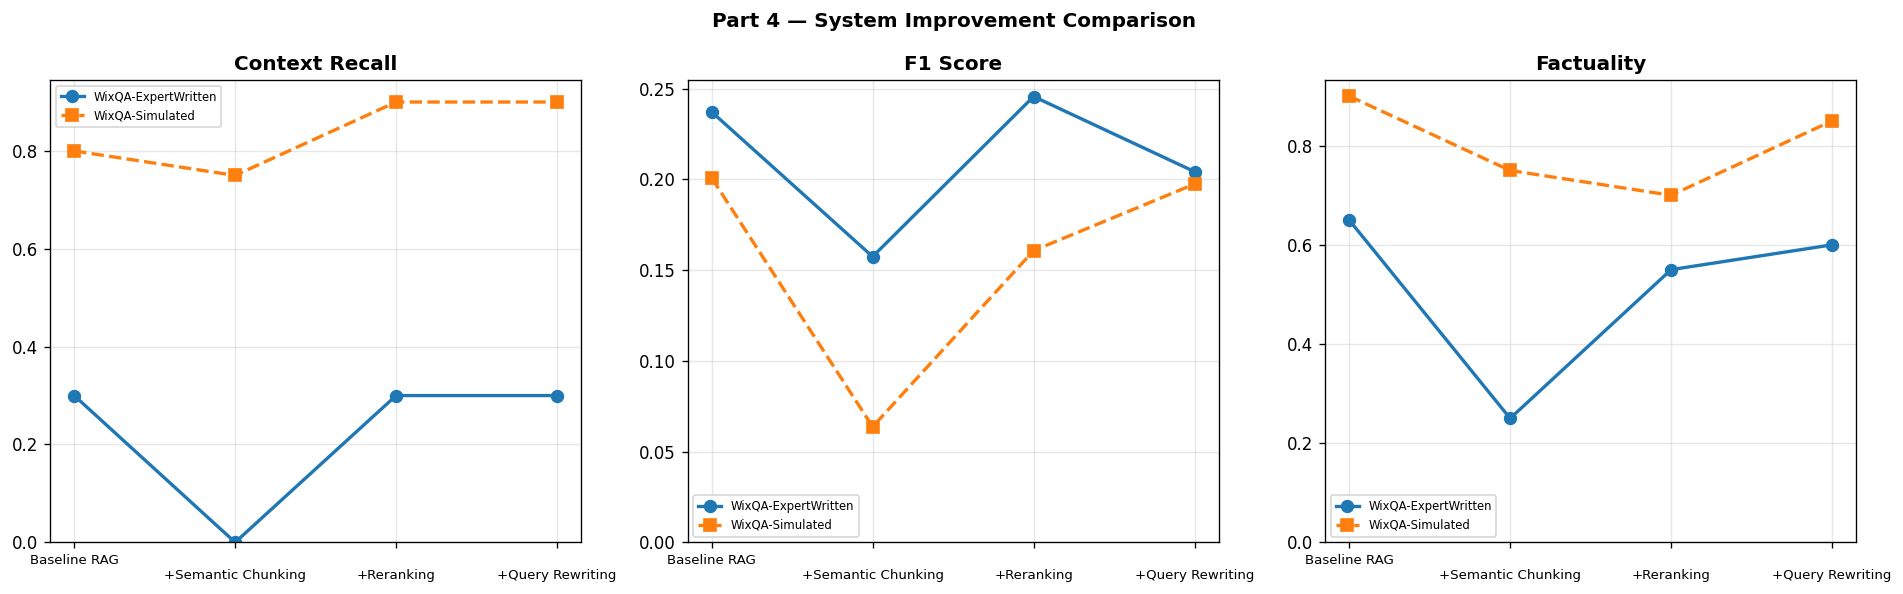

Plot saved: part4_improvements.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

systems = ['Baseline RAG', '+ Semantic Chunking', '+ Reranking', '+ Query Rewriting']

for ax_idx, (metric, title) in enumerate([
    ('Context Recall', 'Context Recall'),
    ('F1', 'F1 Score'),
    ('Factuality', 'Factuality'),
]):
    ax = axes[ax_idx]
    for ds, marker, ls in [('WixQA-ExpertWritten', 'o', '-'), ('WixQA-Simulated', 's', '--')]:
        vals = [
            comp_df[(comp_df.System == s) & (comp_df.Dataset == ds)][metric].values[0]
            for s in systems
        ]
        ax.plot(range(len(systems)), vals, marker=marker, linestyle=ls, label=ds, linewidth=2, markersize=7)

    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels([s.replace('+ ', '\n+') for s in systems], fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Part 4 — System Improvement Comparison', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'part4_improvements.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot saved: part4_improvements.png')

In [27]:
metrics = ['Context Recall', 'F1', 'ROUGE-1', 'ROUGE-2', 'Factuality']
delta_rows = []

for ds in ['WixQA-ExpertWritten', 'WixQA-Simulated']:
    base = comp_df[(comp_df.System == 'Baseline RAG') & (comp_df.Dataset == ds)].iloc[0]
    for sys in ['+ Semantic Chunking', '+ Reranking', '+ Query Rewriting']:
        row = comp_df[(comp_df.System == sys) & (comp_df.Dataset == ds)].iloc[0]
        d = {'System': sys, 'Dataset': ds}
        for m in metrics:
            d[f'Δ{m}'] = round(row[m] - base[m], 4)
        delta_rows.append(d)

delta_df = pd.DataFrame(delta_rows)
print('\nDelta vs Baseline:')
print(delta_df.to_string(index=False))


Delta vs Baseline:
             System             Dataset  ΔContext Recall     ΔF1  ΔROUGE-1  ΔROUGE-2  ΔFactuality
+ Semantic Chunking WixQA-ExpertWritten            -0.30 -0.0797   -0.0882   -0.0801        -0.40
        + Reranking WixQA-ExpertWritten             0.00  0.0085    0.0153   -0.0048        -0.10
  + Query Rewriting WixQA-ExpertWritten             0.00 -0.0329   -0.0340   -0.0306        -0.05
+ Semantic Chunking     WixQA-Simulated            -0.05 -0.1370   -0.1635   -0.1243        -0.15
        + Reranking     WixQA-Simulated             0.10 -0.0400   -0.0505   -0.0400        -0.20
  + Query Rewriting     WixQA-Simulated             0.10 -0.0033   -0.0132    0.0033        -0.05


In [28]:
gen_df = pd.DataFrame(baseline_results)

grid_df.to_csv(RESULTS_DIR / 'results_part1_grid.csv', index=False)
p2_df.to_csv(RESULTS_DIR / 'results_part2_retrieval.csv', index=False)
gen_df.to_csv(RESULTS_DIR / 'results_part3_generation.csv', index=False)
comp_df.to_csv(RESULTS_DIR / 'results_part4_comparison.csv', index=False)
delta_df.to_csv(RESULTS_DIR / 'results_part4_deltas.csv', index=False)

print('All result tables exported to CSV.')

All result tables exported to CSV.
